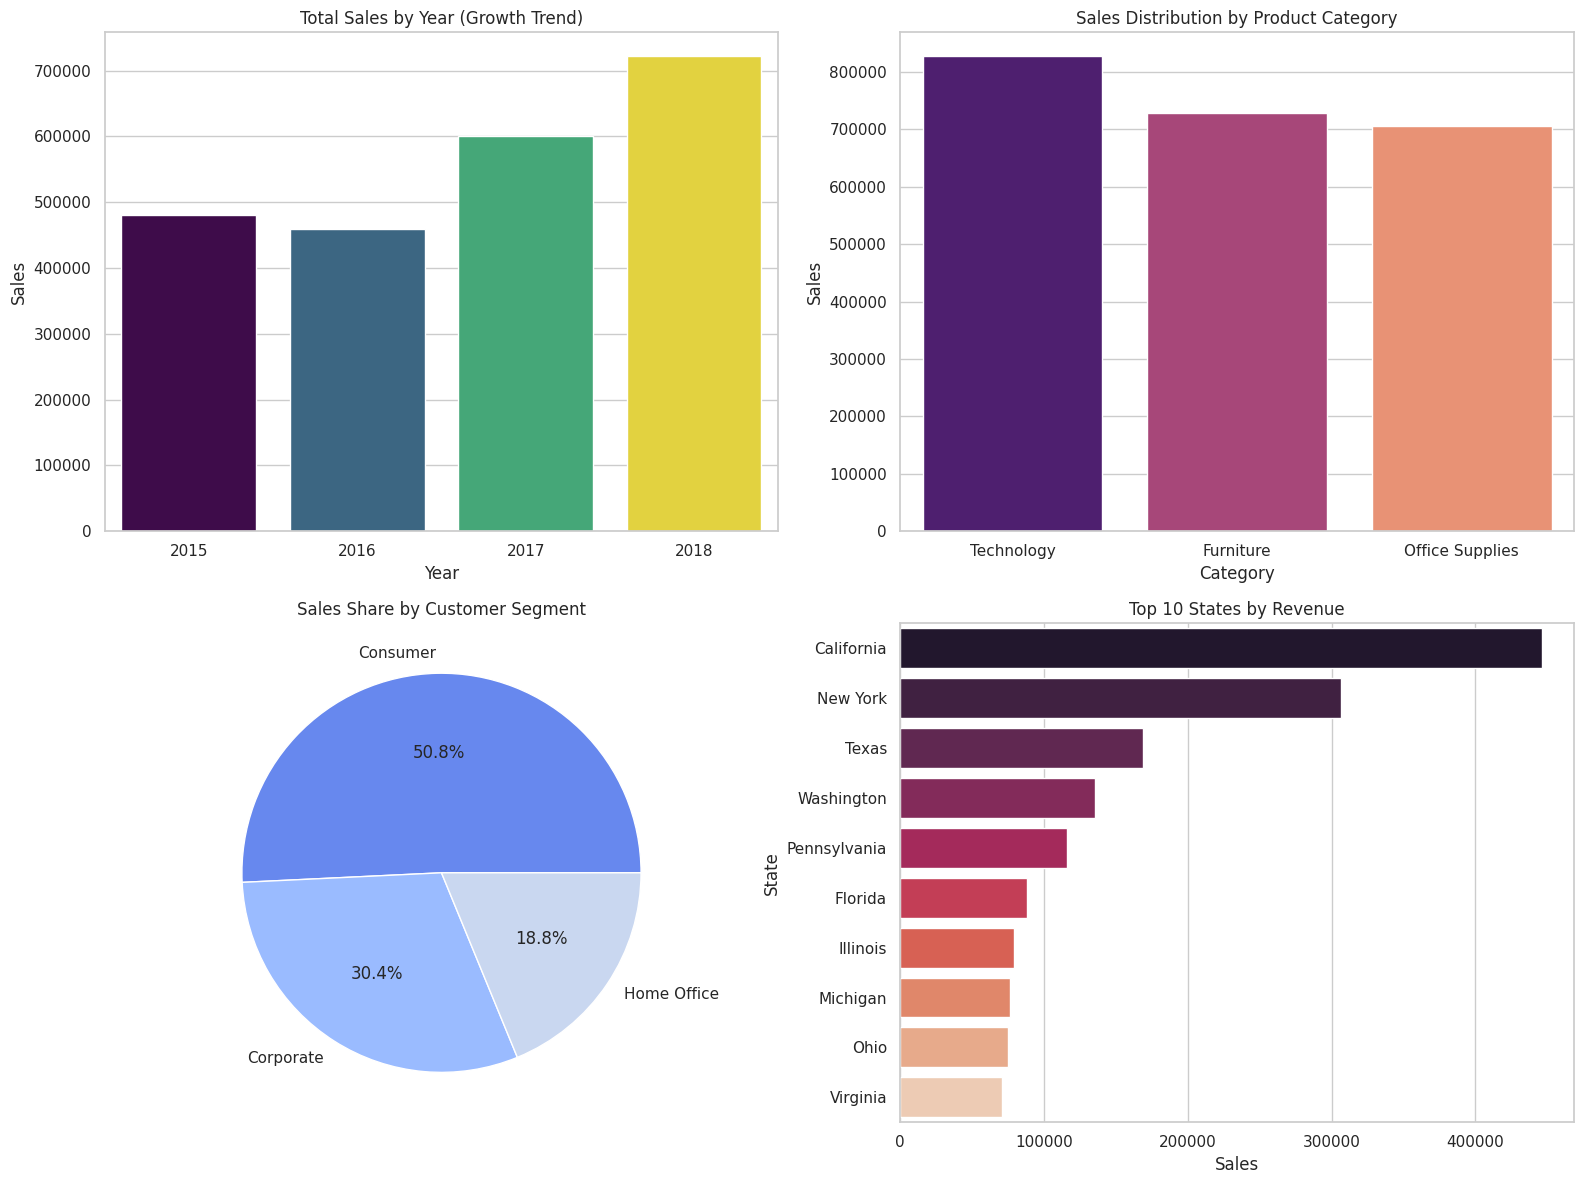

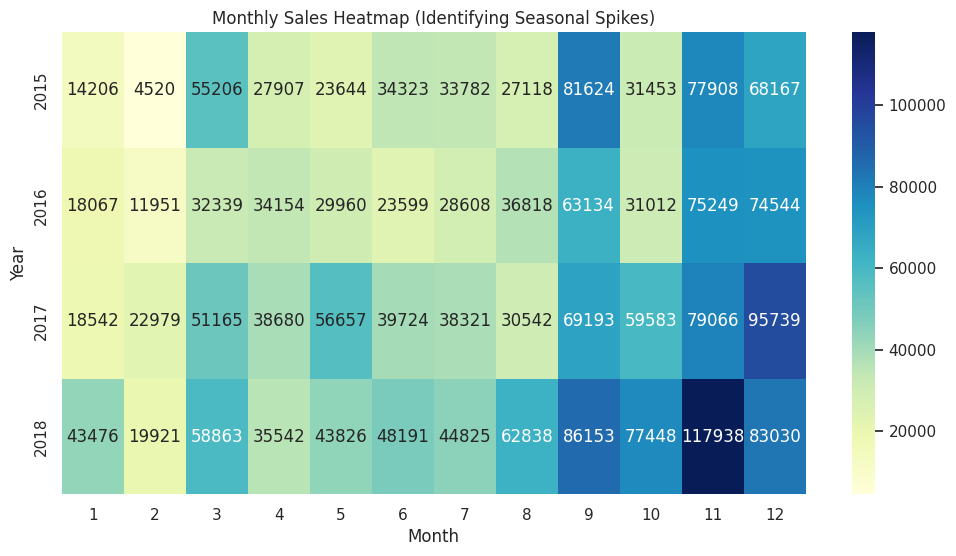

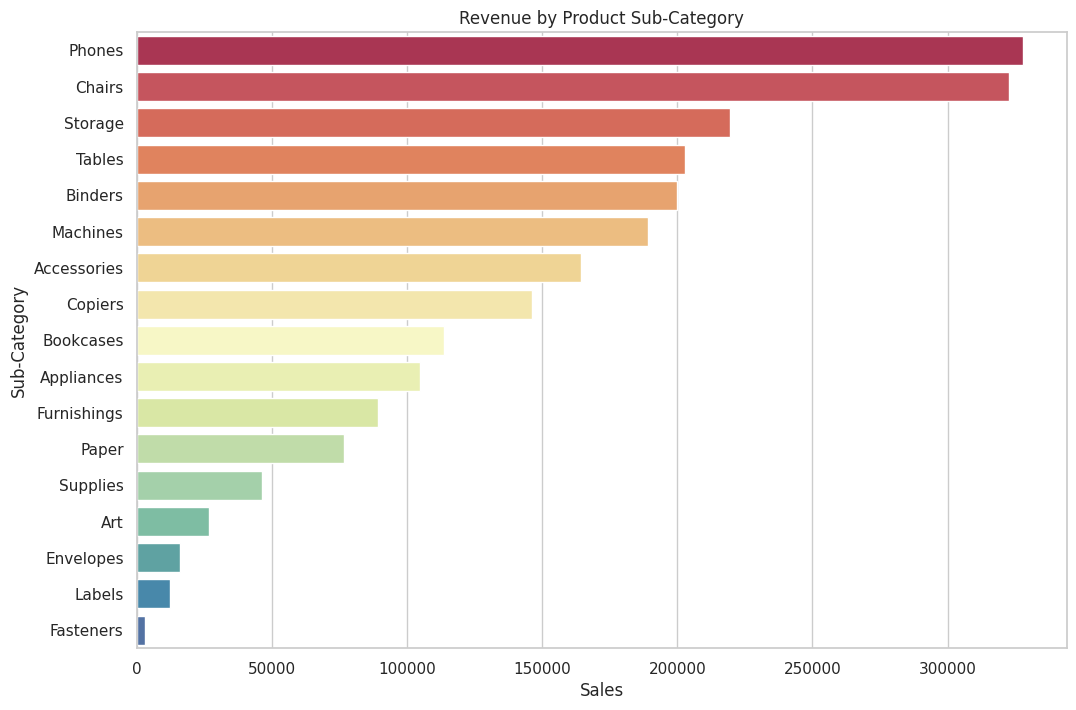

Analysis Complete.
Total Revenue Generated: $2,261,536.78
Top State: California
Top Category: Technology


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dataset
df = pd.read_csv('/content/RetailDataset.csv')

# 2. Data Cleaning & Preprocessing
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['YearMonth'] = df['Order Date'].dt.to_period('M')

# Handle missing values
df['Postal Code'] = df['Postal Code'].fillna(0)

# 3. Exploratory Data Analysis (EDA)

yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()
monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str) # Convert for plotting

category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False).reset_index()
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).reset_index()

state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

# 4. Data Visualization

sns.set(style="whitegrid")
plt.figure(figsize=(16, 12))

#1: Annual Growth
plt.subplot(2, 2, 1)
sns.barplot(data=yearly_sales, x='Year', y='Sales', palette='viridis', hue='Year', legend=False)
plt.title('Total Sales by Year (Growth Trend)')

#2: Category Performance
plt.subplot(2, 2, 2)
sns.barplot(data=category_sales, x='Category', y='Sales', palette='magma', hue='Category', legend=False)
plt.title('Sales Distribution by Product Category')

#3: Segment Contribution
plt.subplot(2, 2, 3)
plt.pie(segment_sales['Sales'], labels=segment_sales['Segment'], autopct='%1.1f%%', colors=sns.color_palette('coolwarm'))
plt.title('Sales Share by Customer Segment')

#4: Top 10 Performing States
plt.subplot(2, 2, 4)
sns.barplot(data=state_sales, x='Sales', y='State', palette='rocket', hue='State', legend=False)
plt.title('Top 10 States by Revenue')

plt.tight_layout()
plt.show()

#Heatmap
plt.figure(figsize=(12, 6))
pivot_table = df.pivot_table(index='Year', columns='Month', values='Sales', aggfunc='sum')
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap='YlGnBu')
plt.title('Monthly Sales Heatmap (Identifying Seasonal Spikes)')
plt.show()


plt.figure(figsize=(12, 8))
sns.barplot(data=subcat_sales, x='Sales', y='Sub-Category', palette='Spectral', hue='Sub-Category', legend=False)
plt.title('Revenue by Product Sub-Category')
plt.show()

# 5. Conclusions
print("Analysis Complete.")
print(f"Total Revenue Generated: ${df['Sales'].sum():,.2f}")
print(f"Top State: {state_sales.iloc[0]['State']}")
print(f"Top Category: {category_sales.iloc[0]['Category']}")

**Summary**

---


Objective:
To identify seasonal trends, high-performing product categories, and key geographic markets to inform business strategy.

Data Profile: The dataset includes features such as order dates, sales figures, product categories (Technology, Furniture, Office Supplies), customer segments, and geographic locations (States and Regions).

Key Insights
Seasonal Peaks: A consistent and significant surge in sales occurs every year during November and December, corresponding with the holiday season.

Revenue Drivers:

Categories:
Technology is the highest revenue-generating category.

Sub-Categories:
Phones and Chairs are the top-selling items.

Customer Segments:
The Consumer segment is the largest contributor to total sales, followed by the Corporate segment.

Geographic Dominance:
California and New York significantly outperform all other states, making the West and East the most profitable regions.

Visualizations Created:

1.Sales Trends:
Yearly bar charts and monthly line plots showing growth and seasonality.

2.Product Performance:
Category and Sub-category breakdowns using bar charts.

3.Geographic Mapping:
A ranking of the top 10 states by total revenue.

4.Operational Heatmap:
A Monthly vs Yearly heatmap highlighting the intensity of sales at the end of each calendar year.

**Final Conclusion:**

The business shows steady year-over-year growth with a highly predictable seasonal cycle. To maximize future performance, the company should optimize inventory for Q4, focus marketing efforts on the Technology sector, and consider expanding loyalty programs within the dominant Consumer segment in high-performing states like California.